<a href="https://colab.research.google.com/github/jubaerabdullah-io/da/blob/main/agriana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Cell 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [25]:
from google.colab import files
uploaded = files.upload()


Saving data.csv to data (1).csv


In [26]:
import pandas as pd

df = pd.read_csv("data.csv", sep=None, engine="python")
df.head()

,Year,Division,District,Upazila,Upazila_area_ha,Total_cropland_ha,Flooded_area_2024_ha,Flooded_area_pct_2024,Flooded_cropland_2024_ha,Flooded_cropland_pct_2024,Total_population_2022,Rural_population_2022,Rural_population_pct,Agriculture_population_2022,Agriculture_population_pct,Poverty_rate_2022_pct,Rice_area_ha_2024_optional,Rice_production_ton_2024_optional,N_Flooded_area_pct,N_Total_cropland_ha,N_Flooded_cropland_ha,N_Flooded_cropland_pct,N_Rural_population_pct,N_Agriculture_population_pct,N_Poverty_rate,N_Rice_area,N_Rice_production,Hazard_score,Exposure_score,Vulnerability_score,Final_AFES_exposure_only,AFES_class,Final_AFRI_full_risk,AFRI_class,Data_notes
0,2024,Sylhet,Maulvibazar,Juri,24370.3200,8129.4600,3900.4100,16.0000,2187.0700,26.9000,"162,572","138,967",85.4800,"18,122",11.1500,25.8000,NaN,NaN,0.1710,0.0660,0.0680,0.2800,0.6350,0.2340,0.4680,NaN,NaN,0.1710,0.1380,0.4460,0.1510,Very low,0.2110,Low,NaN
1,2024,Sylhet,Sunamganj,Derai,40649.0400,25854.9600,36029.7000,88.6400,23901.2500,92.4400,"253,705","208,366",82.1300,"48,667",19.1800,19.1000,NaN,NaN,0.9610,0.5610,0.7900,0.9850,0.5400,0.7140,0.2980,NaN,NaN,0.9610,0.7790,0.5170,0.8520,Very high,0.7900,High,NaN
2,2024,Sylhet,Sunamganj,Sulla,26367.8200,20767.3800,24307.6700,92.1900,19495.2600,93.8700,"117,630","107,869",91.7000,"28,184",23.9600,34.8000,NaN,NaN,1.0000,0.4190,0.6430,1.0000,0.8110,1.0000,0.6970,NaN,NaN,1.0000,0.6880,0.8360,0.8130,Very high,0.8270,Very high,NaN
3,2024,Sylhet,Habiganj,Lakhai,19077.2800,16820.7900,11109.1200,58.2300,10400.1600,61.8300,"158,717","118,828",74.8700,"19,936",12.5600,10.2000,NaN,NaN,0.6300,0.3090,0.3410,0.6560,0.3340,0.3180,0.0710,NaN,NaN,0.6300,0.4350,0.2410,0.5130,Moderate,0.4650,Moderate,NaN
4,2024,Sylhet,Habiganj,Bahubal,26469.6800,13973.7400,6305.0400,23.8200,6146.5500,43.9900,"219,377","207,576",94.6200,"33,744",15.3800,20.3000,NaN,NaN,0.2560,0.2290,0.2000,0.4640,0.8940,0.4870,0.3280,NaN,NaN,0.2560,0.2980,0.5700,0.2810,Low,0.3370,Low,NaN


In [27]:
# Cell 3: Clean numeric columns

for col in df.columns:
    if df[col].dtype == "object":
        cleaned = df[col].astype(str).str.strip().str.replace(",", "", regex=False)
        converted = pd.to_numeric(cleaned, errors="coerce")

        if converted.notna().sum() > 0 and col not in [
            "Division", "District", "Upazila", "AFES_class", "AFRI_class"
        ]:
            df[col] = converted

df.dtypes

,0
Year,int64
Division,object
District,object
Upazila,object
Upazila_area_ha,float64
Total_cropland_ha,float64
Flooded_area_2024_ha,float64
Flooded_area_pct_2024,float64
Flooded_cropland_2024_ha,float64
Flooded_cropland_pct_2024,float64


In [28]:
# Cell 4: Select variables

target = "Final_AFRI_full_risk"

selected_variables = [
    "Flooded_cropland_pct_2024",
    "Poverty_rate_2022_pct",
    "Agriculture_population_pct",
    "Rural_population_pct",
    "Total_cropland_ha"
]

extra_variables = [
    "Flooded_area_pct_2024",
    "Flooded_cropland_2024_ha",
    "Total_population_2022",
    "Agriculture_population_2022",
    "Hazard_score",
    "Exposure_score",
    "Vulnerability_score"
]

all_variables = selected_variables + extra_variables

all_variables = [v for v in all_variables if v in df.columns]
selected_variables = [v for v in selected_variables if v in df.columns]

print("Target variable:", target)
print("Selected variables:", selected_variables)

Target variable: Final_AFRI_full_risk
Selected variables: ['Flooded_cropland_pct_2024', 'Poverty_rate_2022_pct', 'Agriculture_population_pct', 'Rural_population_pct', 'Total_cropland_ha']


In [29]:
# Cell 5: Pearson and Spearman correlation with p-values

results = []

for var in all_variables:
    temp = df[[var, target]].dropna()

    pearson_r, pearson_p = pearsonr(temp[var], temp[target])
    spearman_rho, spearman_p = spearmanr(temp[var], temp[target])

    results.append({
        "Variable": var,
        "N": len(temp),
        "Pearson_r": pearson_r,
        "Pearson_p_value": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p_value": spearman_p
    })

corr_results = pd.DataFrame(results)
corr_results = corr_results.sort_values("Pearson_r", ascending=False)

corr_results

,Variable,N,Pearson_r,Pearson_p_value,Spearman_rho,Spearman_p_value
9,Hazard_score,38,0.9535,0.0000,0.9540,0.0000
5,Flooded_area_pct_2024,38,0.9535,0.0000,0.9547,0.0000
0,Flooded_cropland_pct_2024,38,0.9324,0.0000,0.9519,0.0000
10,Exposure_score,38,0.9257,0.0000,0.9100,0.0000
6,Flooded_cropland_2024_ha,38,0.9075,0.0000,0.8991,0.0000
2,Agriculture_population_pct,38,0.7464,0.0000,0.7164,0.0000
11,Vulnerability_score,38,0.5619,0.0002,0.5198,0.0008
4,Total_cropland_ha,38,0.5156,0.0009,0.4168,0.0092
1,Poverty_rate_2022_pct,38,0.3354,0.0395,0.2963,0.0709
8,Agriculture_population_2022,38,0.1868,0.2614,0.0592,0.7241


In [30]:
# Cell 6: Main 5-variable correlation result

main_corr_results = corr_results[
    corr_results["Variable"].isin(selected_variables)
].copy()

main_corr_results = main_corr_results.sort_values("Pearson_r", ascending=False)

main_corr_results

,Variable,N,Pearson_r,Pearson_p_value,Spearman_rho,Spearman_p_value
0,Flooded_cropland_pct_2024,38,0.9324,0.0000,0.9519,0.0000
2,Agriculture_population_pct,38,0.7464,0.0000,0.7164,0.0000
4,Total_cropland_ha,38,0.5156,0.0009,0.4168,0.0092
1,Poverty_rate_2022_pct,38,0.3354,0.0395,0.2963,0.0709
3,Rural_population_pct,38,0.1780,0.2849,0.2214,0.1817


In [31]:
# Cell 7: Pearson correlation matrix

corr_matrix = df[selected_variables + [target]].corr(method="pearson")

corr_matrix

,Flooded_cropland_pct_2024,Poverty_rate_2022_pct,Agriculture_population_pct,Rural_population_pct,Total_cropland_ha,Final_AFRI_full_risk
Flooded_cropland_pct_2024,1.0000,0.2821,0.6093,0.0065,0.2742,0.9324
Poverty_rate_2022_pct,0.2821,1.0000,0.4370,0.1767,-0.1554,0.3354
Agriculture_population_pct,0.6093,0.4370,1.0000,0.3455,0.2355,0.7464
Rural_population_pct,0.0065,0.1767,0.3455,1.0000,0.1947,0.1780
Total_cropland_ha,0.2742,-0.1554,0.2355,0.1947,1.0000,0.5156
Final_AFRI_full_risk,0.9324,0.3354,0.7464,0.1780,0.5156,1.0000


In [32]:
# Cell 8: Spearman correlation matrix

spearman_matrix = df[selected_variables + [target]].corr(method="spearman")

spearman_matrix

,Flooded_cropland_pct_2024,Poverty_rate_2022_pct,Agriculture_population_pct,Rural_population_pct,Total_cropland_ha,Final_AFRI_full_risk
Flooded_cropland_pct_2024,1.0000,0.2528,0.5840,0.0686,0.3240,0.9519
Poverty_rate_2022_pct,0.2528,1.0000,0.3939,0.1052,-0.1700,0.2963
Agriculture_population_pct,0.5840,0.3939,1.0000,0.3886,0.2969,0.7164
Rural_population_pct,0.0686,0.1052,0.3886,1.0000,0.1292,0.2214
Total_cropland_ha,0.3240,-0.1700,0.2969,0.1292,1.0000,0.4168
Final_AFRI_full_risk,0.9519,0.2963,0.7164,0.2214,0.4168,1.0000


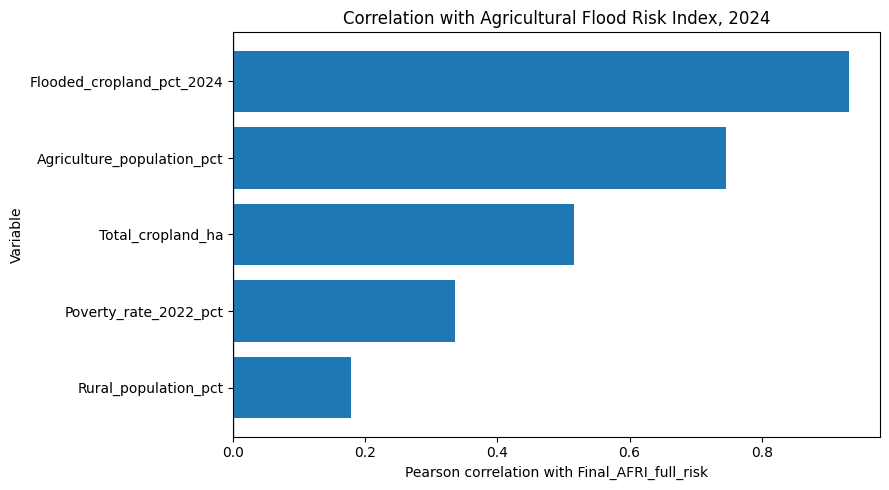

In [33]:
# Cell 9: Bar chart of Pearson correlation

plot_data = main_corr_results.sort_values("Pearson_r", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["Variable"], plot_data["Pearson_r"])
plt.xlabel("Pearson correlation with Final_AFRI_full_risk")
plt.ylabel("Variable")
plt.title("Correlation with Agricultural Flood Risk Index, 2024")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

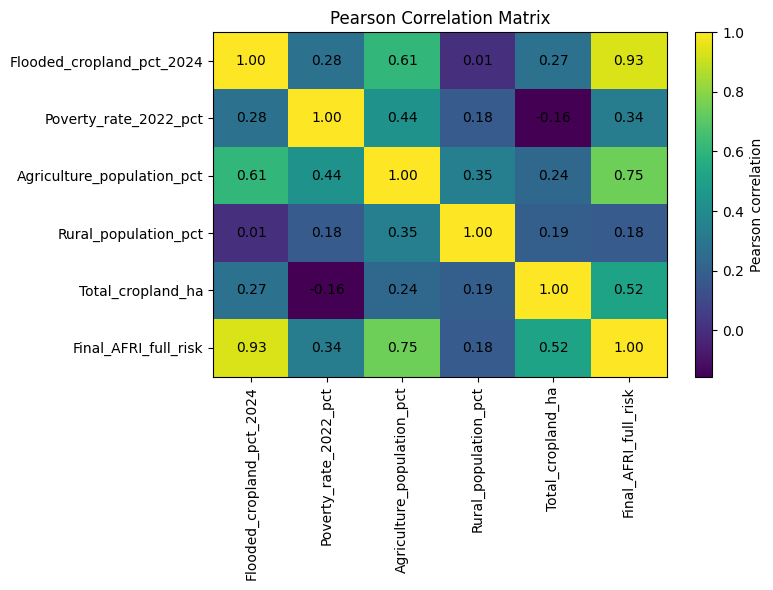

In [34]:
# Cell 10: Correlation heatmap using matplotlib

matrix = corr_matrix.values
labels = corr_matrix.columns

plt.figure(figsize=(8, 6))
plt.imshow(matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Pearson Correlation Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

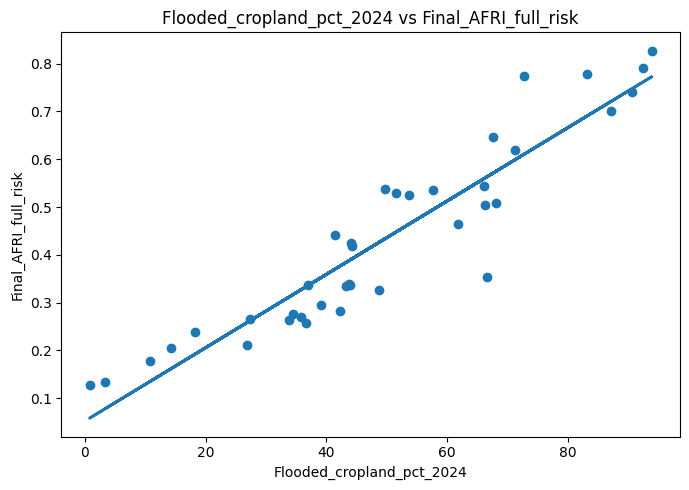

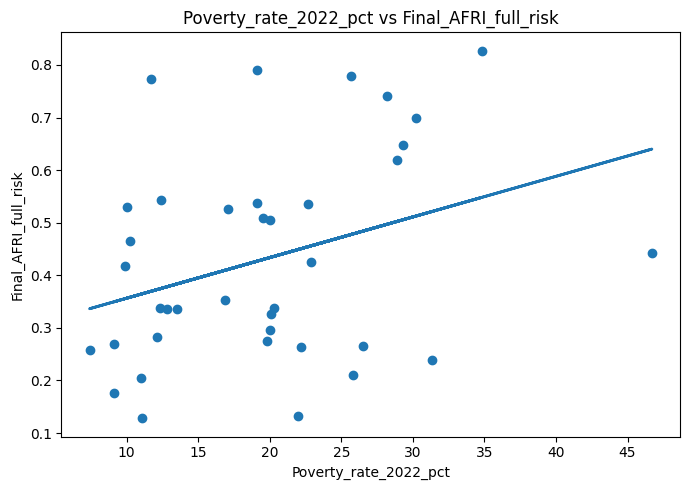

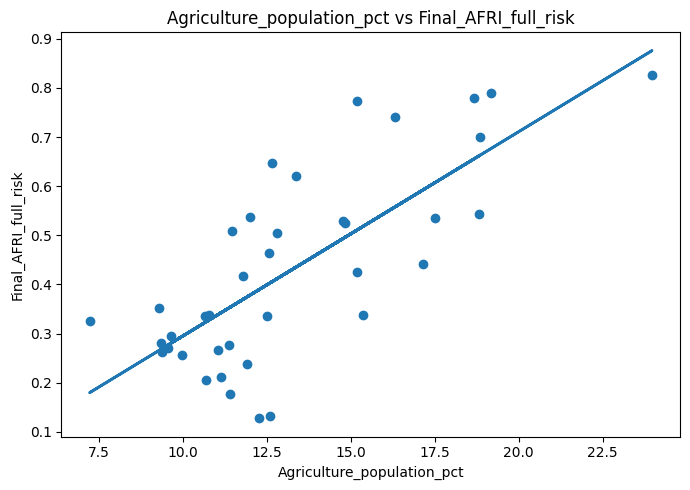

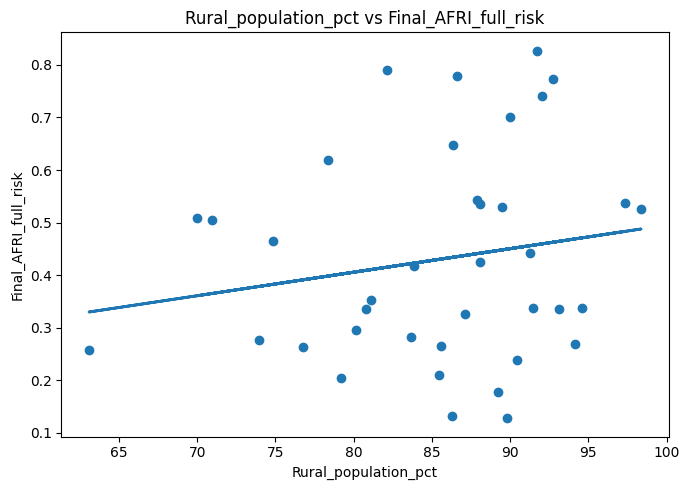

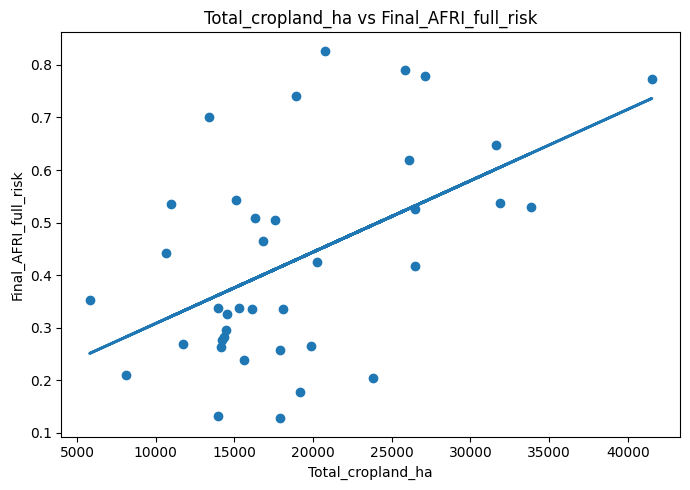

In [35]:
# Cell 11: Scatter plots with trend lines

for var in selected_variables:
    temp = df[[var, target, "Upazila"]].dropna()

    x = temp[var]
    y = temp[target]

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y)
    plt.plot(x, y_pred, linewidth=2)
    plt.xlabel(var)
    plt.ylabel(target)
    plt.title(f"{var} vs {target}")
    plt.tight_layout()
    plt.show()

In [36]:
# Cell 12: District-wise average AFRI score

district_risk = (
    df.groupby("District")[target]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

district_risk

,count,mean,min,max
District,,,,
Sunamganj,11,0.6375,0.4250,0.8270
Habiganj,8,0.4012,0.1280,0.7740
Sylhet,12,0.3705,0.2630,0.5370
Maulvibazar,7,0.2389,0.1330,0.3360


In [38]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=district_risk)

MessageError: Error: credential propagation was unsuccessful

In [37]:
# Cell 13: Export results

corr_results.to_csv("correlation_results_all_variables.csv", index=False)
main_corr_results.to_csv("correlation_results_main_variables.csv", index=False)
corr_matrix.to_csv("pearson_correlation_matrix.csv")
spearman_matrix.to_csv("spearman_correlation_matrix.csv")

print("Correlation result files exported successfully.")

Correlation result files exported successfully.
